# Robust regression — fitting a line that ignores the broken rows

## The story

Farhan runs a courier desk. Every parcel gets weighed, and the billing system
records what the customer paid. He wanted the obvious thing: **a line from
parcel weight to delivery cost**, so a quote could be given at the counter
before anything was weighed twice.

He fitted `LinearRegression` on a year of records. The line came out wrong —
too high for every small parcel, and almost flat, so a 5 kg box and a 20 kg box
were quoted nearly the same price.

**Here is why it failed.** One of the counter terminals had a fault. When a card
payment timed out, it still wrote a row, and it wrote the amount as a fixed
₹600. About fifteen rows in every hundred were that ₹600, scattered across
every weight. They were not expensive parcels. They were not parcels at all.

**He deleted them by hand**, refitted, and the line was fine. Next month the
fault came back on a different terminal with a different fixed amount, and he
was back to reading rows one by one.

What Farhan actually needed was not a cleaner spreadsheet. He needed a fitting
method that **finds the pattern the majority of the rows agree on, and refuses
to be moved by the minority** — whatever shape this month's fault takes. That
method is robust regression.

## What this story is actually saying, in plain words

1. **Two kinds of rows are mixed in one table, and nothing marks which is which.**
   - ~85% are real parcels: heavier box → higher price, plus normal small noise.
   - ~15% are fault rows: the terminal gave up and just wrote ₹600, no matter
     if the box was 2 kg or 20 kg.

2. **`LinearRegression` trusts every row equally.** It has no idea some rows are
   fake. It tries to draw one line that keeps *all* rows happy — real and fake.
   The fake ₹600 rows (cheap price on heavy boxes) pull the line down and flatten
   it, so it stops matching the real parcels properly.

3. **Deleting the bad rows by hand only worked because he knew the fault value
   was ₹600 this time.** It is not a real fix — it is a one-time patch.

4. **Next month the fault changed shape** (a different terminal, a different
   fixed number, e.g. ₹450). His hand-made rule ("delete rows = ₹600") no longer
   catches anything. He is stuck manually checking rows again, forever.

5. **The real requirement:** a method that looks at the data and figures out on
   its own *"most rows agree on this pattern, a few don't — ignore the few"* —
   without being told in advance what the bad rows look like.

6. **That method is robust regression.** `RANSACRegressor`, `HuberRegressor`,
   and `TheilSenRegressor` all do this: they fit the line the majority agrees on
   and stay stable even if a chunk of rows is corrupted, whatever form that
   corruption takes.

> 📘 **Instructor Curriculum** — Session 22.


## Setup

Nothing new to install. `RANSACRegressor`, `HuberRegressor` and
`TheilSenRegressor` all live in `sklearn.linear_model`, next to
`LinearRegression`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.linear_model import (LinearRegression, RANSACRegressor,
                                  HuberRegressor, TheilSenRegressor)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

OK, BAD, OLS = "#1f7a8c", "#e4572e", "#222222"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10})
rng = np.random.default_rng(7)

## Farhan's data

The class notebook built this with `make_regression` and then overwrote the
first slice of `y` with a constant. Same thing here, smaller so every plot
redraws quickly.

- **1 600 honest rows** — cost really does rise with weight, plus ordinary noise
- **240 broken rows** (15%) — the terminal wrote a flat ₹600 regardless of weight

In [2]:
n, frac_bad = 1600, 0.15
n_bad = int(n * frac_bad)

weight, cost, TRUE_SLOPE = make_regression(
    n_samples=n, n_features=1, noise=10, random_state=0, coef=True)
TRUE_SLOPE = float(TRUE_SLOPE)                           # the honest relationship

bad = np.zeros(n, dtype=bool)
bad[:n_bad] = True                                       # the faulty terminal's rows
cost[bad] = 600 + rng.normal(size=n_bad)                 # a flat amount, every time

print(f"rows            : {n}")
print(f"broken rows     : {bad.sum()}  ({bad.mean():.0%})")
print(f"true slope      : {TRUE_SLOPE:.1f} rupees per unit of weight")
print(f"cost range, good: {cost[~bad].min():.0f} to {cost[~bad].max():.0f}")
print(f"cost range, bad : {cost[bad].min():.0f} to {cost[bad].max():.0f}")

rows            : 1600
broken rows     : 240  (15%)
true slope      : 34.4 rupees per unit of weight
cost range, good: -108 to 111
cost range, bad : 597 to 602


Now fit the ordinary line on everything, the way Farhan did, and draw it against
the line the honest rows actually describe.

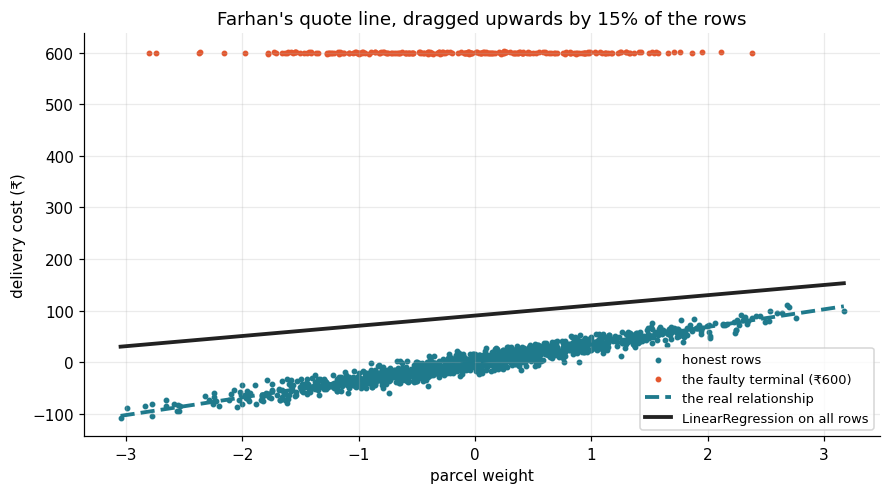

slope wanted :     34.2
slope fitted :     19.8   (58% of it)
intercept    :      0.1  ->  90.4


In [3]:
ols = LinearRegression().fit(weight, cost)
truth = LinearRegression().fit(weight[~bad], cost[~bad])   # what he should have got

grid = np.linspace(weight.min(), weight.max(), 200).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.scatter(weight[~bad], cost[~bad], s=8, c=OK,  label="honest rows")
ax.scatter(weight[bad],  cost[bad],  s=8, c=BAD, label="the faulty terminal (₹600)")
ax.plot(grid, truth.predict(grid), c=OK,  lw=2.5, ls="--", label="the real relationship")
ax.plot(grid, ols.predict(grid),   c=OLS, lw=2.5, label="LinearRegression on all rows")
ax.set(title="Farhan's quote line, dragged upwards by 15% of the rows",
       xlabel="parcel weight", ylabel="delivery cost (₹)")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

print(f"slope wanted : {truth.coef_[0]:8.1f}")
print(f"slope fitted : {ols.coef_[0]:8.1f}   ({ols.coef_[0] / truth.coef_[0]:.0%} of it)")
print(f"intercept    : {truth.intercept_:8.1f}  ->  {ols.intercept_:.1f}")

The black line sits above almost every real parcel and it has lost most of its
tilt. Fifteen rows in a hundred did that.

## Why the square is the problem

`LinearRegression` picks the line with the smallest **sum of squared** errors.
The square is what makes it fragile.

A row that misses by 10 contributes 100. A row that misses by 100 contributes
**10 000** — the same as one hundred ordinary rows put together. So the fit has
no choice: moving towards the far-away rows saves more than staying with the
crowd.

The three curves below are three ways of charging for the same mistake.

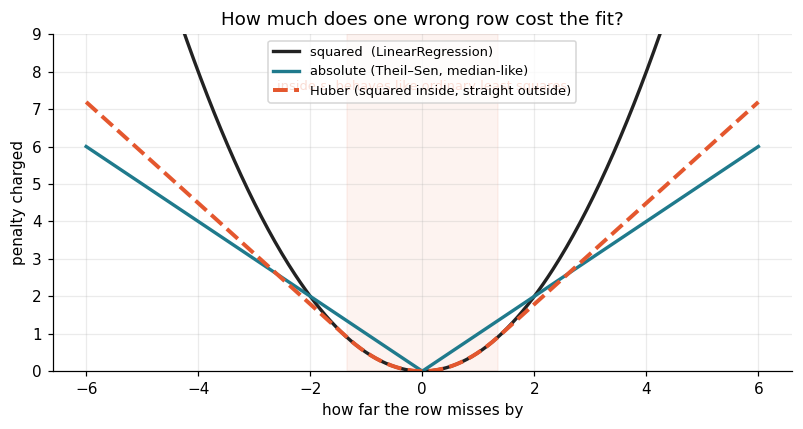

In [4]:
e = np.linspace(-6, 6, 400)
eps = 1.35                                   # sklearn's default for Huber
huber = np.where(np.abs(e) <= eps, .5 * e**2, eps * (np.abs(e) - .5 * eps))

fig, ax = plt.subplots(figsize=(7.4, 4.0))
ax.plot(e, .5 * e**2,      c=OLS, lw=2.2, label="squared  (LinearRegression)")
ax.plot(e, np.abs(e),      c=OK,  lw=2.2, label="absolute (Theil–Sen, median-like)")
ax.plot(e, huber,          c=BAD, lw=2.6, ls="--", label="Huber (squared inside, straight outside)")
ax.axvspan(-eps, eps, color=BAD, alpha=.07)
ax.annotate("inside ε: behaves like ordinary least squares", xy=(0, 7.5),
            ha="center", fontsize=8.5, color=BAD)
ax.set(title="How much does one wrong row cost the fit?",
       xlabel="how far the row misses by", ylabel="penalty charged", ylim=(0, 9))
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

Read the right-hand edge. The squared curve is still climbing steeply, so a row
far out there keeps buying influence. The other two flatten into straight lines:
past a point, being wrong by 50 costs barely more than being wrong by 40, and a
broken row stops being worth chasing.

That single change is what "robust" means here.

## Breakdown point

The standard way to compare these methods is the **breakdown point**: the
fraction of the data that has to be corrupted before the fit can be pushed
anywhere at all.

| Method | Breakdown point |
|---|---|
| `LinearRegression` | **0%** — one row, moved far enough, moves the line |
| `HuberRegressor` | 0% in theory, but influence grows very slowly |
| `TheilSenRegressor` | about 29% |
| `RANSACRegressor` | up to about 50% |

"0% for ordinary least squares" sounds like an exaggeration. It is not. Take
the clean data, pick **one** row, and drag it upwards.

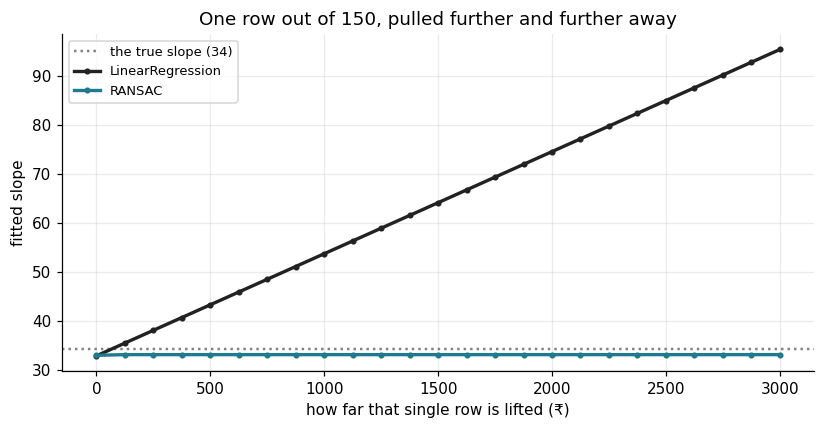

OLS slope    :   32.9  ->    95.3   (2.9x, and still climbing)
RANSAC slope :   33.0  ->    33.2


In [5]:
Xc, yc = weight[~bad][:150], cost[~bad][:150]     # 150 honest rows, nothing wrong with them
victim = np.abs(Xc.ravel()).argmax()              # the heaviest parcel: it has the most pull

lifts = np.linspace(0, 3000, 25)
slope_ols, slope_ran = [], []
for lift in lifts:
    y1 = yc.copy()
    y1[victim] += lift                            # one single row, pulled away
    slope_ols.append(LinearRegression().fit(Xc, y1).coef_[0])
    slope_ran.append(RANSACRegressor(random_state=0).fit(Xc, y1).estimator_.coef_[0])

fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.axhline(TRUE_SLOPE, c="grey", ls=":", lw=1.6, label=f"the true slope ({TRUE_SLOPE:.0f})")
ax.plot(lifts, slope_ols, c=OLS, lw=2.2, marker="o", ms=3, label="LinearRegression")
ax.plot(lifts, slope_ran, c=OK,  lw=2.2, marker="o", ms=3, label="RANSAC")
ax.set(title="One row out of 150, pulled further and further away",
       xlabel="how far that single row is lifted (₹)", ylabel="fitted slope")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

print(f"OLS slope    : {slope_ols[0]:6.1f}  ->  {slope_ols[-1]:6.1f}"
      f"   ({slope_ols[-1] / slope_ols[0]:.1f}x, and still climbing)")
print(f"RANSAC slope : {slope_ran[0]:6.1f}  ->  {slope_ran[-1]:6.1f}")

One row out of 150, and the ordinary slope walks away from the truth in a
straight line. It never settles, because there is no limit — keep lifting and it
keeps following. RANSAC is a flat line, because after the first few hundred
rupees that row stops being counted at all.

The row that was moved is the **heaviest parcel**, the one furthest out along
the x axis. That is deliberate: a far-out x has more leverage, so it swings the
line hardest. A row can be dangerous by being extreme in the target, in an
input, or in both.

## RANSAC, in words

**RA**ndom **SA**mple **C**onsensus. The idea is closer to voting than to
fitting, and it is worth knowing before reading the sklearn call.

```text
repeat many times:
    1. pick the smallest number of rows that define a line   (2 rows)
    2. fit a line through just those rows
    3. measure every other row's distance to that line
    4. rows closer than a threshold are its inliers — count them
keep the line with the most inliers
refit properly, on that winning inlier set only
```

Nothing here tries to please the broken rows. A candidate line is only ever
scored by **how many rows agree with it**, and a broken row that disagrees
contributes zero — not a large penalty, zero. That is why 15% of the data
cannot buy anything.

The picture below is step 1 to 4, done three times by hand.

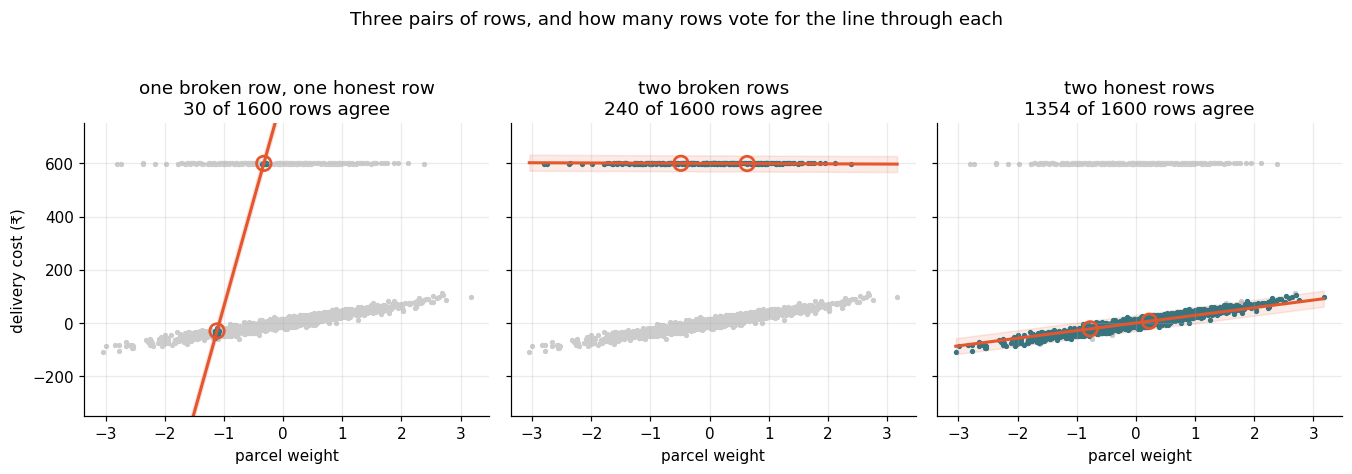

In [6]:
thr = 30                                        # a row within ₹30 counts as agreeing
good_rows, bad_rows = np.where(~bad)[0], np.where(bad)[0]

draws = [(np.array([bad_rows[0], good_rows[-1]]), "one broken row, one honest row"),
         (np.array([bad_rows[1], bad_rows[9]]),   "two broken rows"),
         (np.array([good_rows[0], good_rows[5]]), "two honest rows")]

fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.1), sharey=True)
for ax, (pair, what) in zip(axes, draws):
    m, c0 = np.polyfit(weight[pair].ravel(), cost[pair], 1)
    resid = np.abs(cost - (m * weight.ravel() + c0))
    inlier = resid < thr

    ax.scatter(weight[~inlier], cost[~inlier], s=6, c="#cccccc")
    ax.scatter(weight[inlier],  cost[inlier],  s=6, c=OK)
    ax.plot(grid, m * grid.ravel() + c0, c=BAD, lw=2)
    ax.fill_between(grid.ravel(), m * grid.ravel() + c0 - thr,
                    m * grid.ravel() + c0 + thr, color=BAD, alpha=.12)
    ax.scatter(weight[pair], cost[pair], s=90, facecolor="none",
               edgecolor=BAD, lw=1.8, zorder=5)
    ax.set(title=f"{what}\n{inlier.sum()} of {n} rows agree",
           xlabel="parcel weight", ylim=(-350, 750))

axes[0].set_ylabel("delivery cost (₹)")
fig.suptitle("Three pairs of rows, and how many rows vote for the line through each", y=1.04)
plt.tight_layout(); plt.show()

Two circled rows, one line through them, a band of width `threshold` around it,
and a count of everything inside the band.

The middle panel is the one to look at. A pair of broken rows produces a
perfectly reasonable-looking flat line — and it collects only the other broken
rows, because nothing else in the data is flat. The fault cannot win a vote it
is outnumbered in. The right-hand panel, two ordinary rows, collects almost
everything.

sklearn runs this loop for you.

In [7]:
ran = RANSACRegressor(random_state=0).fit(weight, cost)

inlier = ran.inlier_mask_
print(f"trials run           : {ran.n_trials_}")
mad = np.median(np.abs(cost - np.median(cost)))   # the default threshold sklearn uses
print(f"threshold used       : {mad:.1f}   (median absolute deviation of y)")
print(f"rows kept as inliers : {inlier.sum()} of {n}")
print(f"broken rows kept     : {(inlier & bad).sum()} of {bad.sum()}")
print()
print(f"true slope   : {TRUE_SLOPE:8.1f}")
print(f"RANSAC slope : {ran.estimator_.coef_[0]:8.1f}")
print(f"OLS slope    : {ols.coef_[0]:8.1f}")

trials run           : 4
threshold used       : 29.4   (median absolute deviation of y)
rows kept as inliers : 1353 of 1600
broken rows kept     : 0 of 240

true slope   :     34.4
RANSAC slope :     34.0
OLS slope    :     19.8


`inlier_mask_` is the useful part and it is easy to miss. RANSAC does not just
give a better line — it hands back **which rows it believed**, as a boolean
array. That is a free outlier detector, and Farhan can send exactly those rows
to whoever owns the terminal.

It is not free of cost, though. Look at the last number printed below: a few
perfectly honest rows sat outside the band and were discarded with the rest.
That is the trade you accept — RANSAC would rather lose a good row than keep a
bad one.

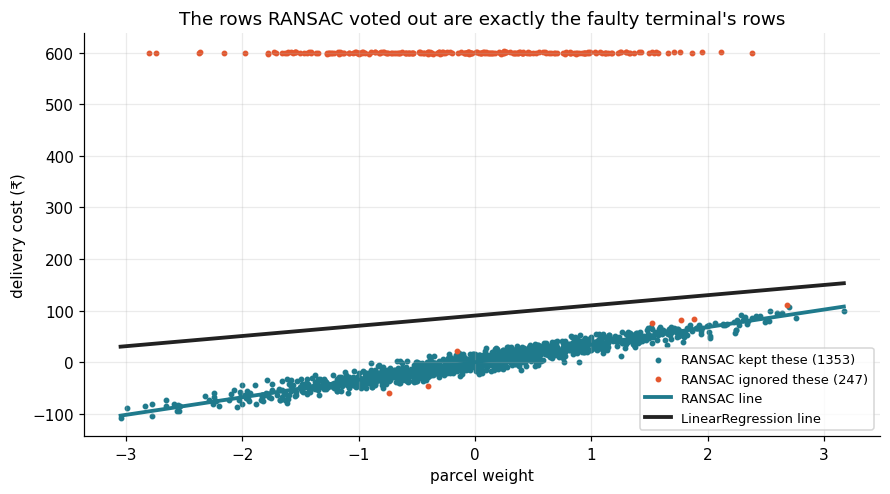

broken rows correctly rejected : 100.0%
honest rows thrown out too     : 7


In [8]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.scatter(weight[inlier],  cost[inlier],  s=8, c=OK,  label=f"RANSAC kept these ({inlier.sum()})")
ax.scatter(weight[~inlier], cost[~inlier], s=8, c=BAD, label=f"RANSAC ignored these ({(~inlier).sum()})")
ax.plot(grid, ran.predict(grid),   c=OK,  lw=2.5, label="RANSAC line")
ax.plot(grid, ols.predict(grid),   c=OLS, lw=2.5, label="LinearRegression line")
ax.set(title="The rows RANSAC voted out are exactly the faulty terminal's rows",
       xlabel="parcel weight", ylabel="delivery cost (₹)")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

print(f"broken rows correctly rejected : {(~inlier & bad).sum() / bad.sum():.1%}")
print(f"honest rows thrown out too     : {(~inlier & ~bad).sum()}")

## Huber — one fit, no voting

RANSAC throws rows away. `HuberRegressor` keeps every row but **caps what a far
row can charge**, using the dashed curve from the loss plot: squared inside
`epsilon` standard deviations, straight-line outside.

`epsilon` is the knob. Smaller means more suspicious; 1.35 is the default and is
a good starting point.

Huber needs its inputs scaled sensibly, because `epsilon` is measured in the
model's own error units. Here the data is already on a reasonable scale.

In [9]:
hub = HuberRegressor(epsilon=1.35).fit(weight, cost)

print(f"slope        : {hub.coef_[0]:8.1f}   (true {TRUE_SLOPE:.1f})")
print(f"rows Huber down-weighted as outliers : {hub.outliers_.sum()} of {n}")

for eps in [1.05, 1.35, 2.0, 5.0]:
    h = HuberRegressor(epsilon=eps, max_iter=500).fit(weight, cost)
    print(f"epsilon={eps:<5} slope={h.coef_[0]:8.1f}   down-weighted={h.outliers_.sum():4d}")

slope        :     33.9   (true 34.4)
rows Huber down-weighted as outliers : 584 of 1600
epsilon=1.05  slope=    33.9   down-weighted=1362
epsilon=1.35  slope=    33.9   down-weighted= 584
epsilon=2.0   slope=    33.4   down-weighted= 245
epsilon=5.0   slope=    19.8   down-weighted=   0


Watch the last column as `epsilon` grows. At 5.0 hardly anything is treated as
an outlier and the slope slides back towards the broken OLS answer — because a
large enough `epsilon` *is* ordinary least squares.

## Theil–Sen — the median of every slope

The third method is the most direct of the three, and it needs no threshold at
all.

Take every pair of rows. Each pair defines a slope. You now have a large pile of
slopes: a pair of honest rows gives roughly the right one, a pair that touches a
₹600 row gives nonsense. **Take the median of the pile.**

A median only asks which value is in the middle. It never asks how far away the
ends are, so the nonsense slopes cannot pull it. It is the mean-versus-median
argument you already know from a skewed column, moved up one level — from a
column of numbers to a line.

pairs sampled : 5000
slope         :     34.7   (true 34.4)


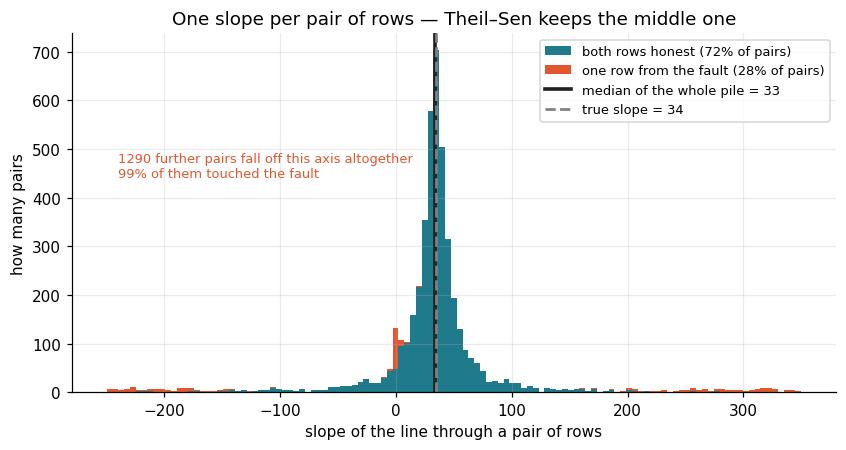

honest pairs         : 72.4%
median of honest only: 34.1
median of everything : 33.3


In [10]:
ts = TheilSenRegressor(random_state=0, max_subpopulation=5000).fit(weight, cost)
print(f"pairs sampled : {ts.n_subpopulation_}")
print(f"slope         : {ts.coef_[0]:8.1f}   (true {TRUE_SLOPE:.1f})")

# the pile of pair-slopes it is taking the median of
idx = rng.choice(n, size=(6000, 2))
idx = idx[idx[:, 0] != idx[:, 1]]
dx = weight[idx[:, 1], 0] - weight[idx[:, 0], 0]
keep = np.abs(dx) > .05
idx, dx = idx[keep], dx[keep]
slopes = (cost[idx[:, 1]] - cost[idx[:, 0]]) / dx
touched = bad[idx].any(axis=1)                # did this pair include a broken row?

LO, HI = -250, 350
bins = np.linspace(LO, HI, 120)
off = ((slopes < LO) | (slopes > HI))

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.hist([slopes[~touched & ~off], slopes[touched & ~off]],
        bins=bins, stacked=True, color=[OK, BAD], edgecolor="none",
        label=[f"both rows honest ({(~touched).mean():.0%} of pairs)",
               f"one row from the fault ({touched.mean():.0%} of pairs)"])
ax.annotate(f"{off.sum()} further pairs fall off this axis altogether\n"
            f"{(off & touched).mean() / off.mean():.0%} of them touched the fault",
            xy=(-240, ax.get_ylim()[1] * .6), fontsize=8.5, color=BAD)
ax.axvline(np.median(slopes), c=OLS, lw=2.4,
           label=f"median of the whole pile = {np.median(slopes):.0f}")
ax.axvline(TRUE_SLOPE, c="grey", lw=1.8, ls="--", label=f"true slope = {TRUE_SLOPE:.0f}")
ax.set(title="One slope per pair of rows — Theil–Sen keeps the middle one",
       xlabel="slope of the line through a pair of rows", ylabel="how many pairs")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

print(f"honest pairs         : {(~touched).mean():.1%}")
print(f"median of honest only: {np.median(slopes[~touched]):.1f}")
print(f"median of everything : {np.median(slopes):.1f}")

The teal peak is narrow and sits on the true slope. The orange is a smear with
no shape at all, plus a spike at zero — that spike is pairs where *both* rows
came from the fault, so both sat at ₹600 and the line through them is flat.

Because teal is still the majority of the pile, the middle value falls inside it
and the median lands on the truth.

Now read the two percentages, because together they explain Theil–Sen's limit.
15% of *rows* are broken, but over a quarter of *pairs* are spoiled — a pair is
ruined if **either** of its rows is bad. Push the contamination further and the
smear becomes the majority, the middle value moves into it, and the method
fails. That is roughly where the 29% in the table comes from.

## All four, on Farhan's problem

The honest test is the one that matters: split the data the way the class
notebook did, fit on the training half, then **score only on the honest test
rows** — because those are the parcels the counter will actually quote.

In [11]:
Xtr, Xte, ytr, yte, btr, bte = train_test_split(
    weight, cost, bad, test_size=.2, random_state=0)

models = {
    "LinearRegression": LinearRegression(),
    "RANSAC":           RANSACRegressor(random_state=0),
    "Huber":            HuberRegressor(epsilon=1.35),
    "Theil–Sen":        TheilSenRegressor(random_state=0, max_subpopulation=5000),
}

rows = {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    slope = (m.estimator_ if name == "RANSAC" else m).coef_[0]
    err = mean_absolute_error(yte[~bte], m.predict(Xte[~bte]))   # honest rows only
    rows[name] = (slope, err)
    print(f"{name:18s} slope={slope:7.1f}   avg error on honest parcels = ₹{err:.1f}")

print(f"\n{'true slope':18s} slope={TRUE_SLOPE:7.1f}")

LinearRegression   slope=   24.4   avg error on honest parcels = ₹87.5


RANSAC             slope=   35.3   avg error on honest parcels = ₹7.8
Huber              slope=   34.0   avg error on honest parcels = ₹8.0
Theil–Sen          slope=   34.2   avg error on honest parcels = ₹7.9

true slope         slope=   34.4


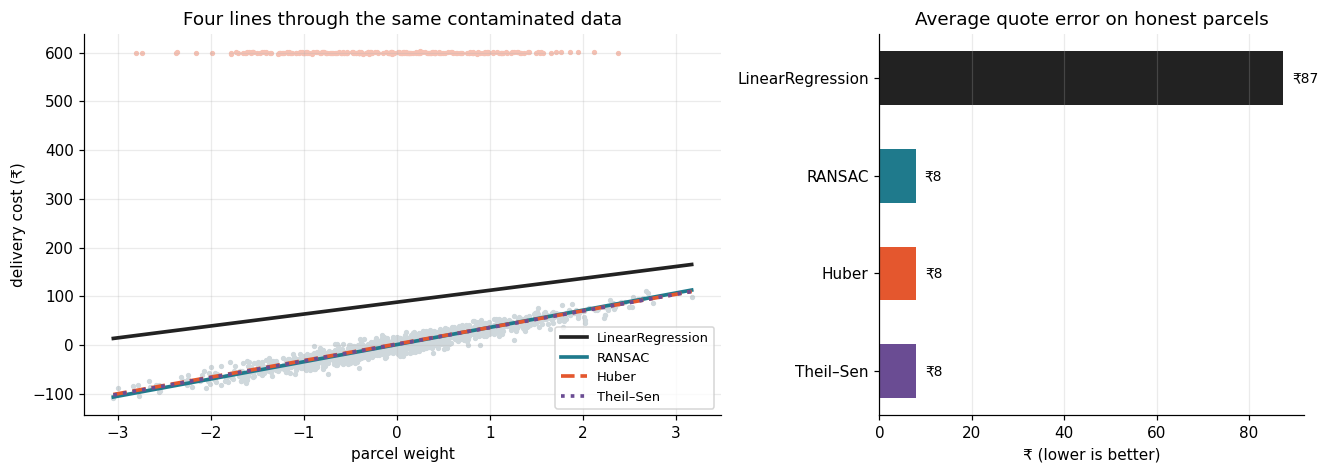

In [12]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.2, 4.4),
                             gridspec_kw={"width_ratios": [1.5, 1]})

a1.scatter(weight[~bad], cost[~bad], s=6, c="#cfd8dc")
a1.scatter(weight[bad],  cost[bad],  s=6, c="#f6c1b3")
colors = {"LinearRegression": OLS, "RANSAC": OK, "Huber": BAD, "Theil–Sen": "#6a4c93"}
styles = {"LinearRegression": "-", "RANSAC": "-", "Huber": "--", "Theil–Sen": ":"}
for name, m in models.items():
    a1.plot(grid, m.predict(grid), c=colors[name], lw=2.4, ls=styles[name], label=name)
a1.set(title="Four lines through the same contaminated data",
       xlabel="parcel weight", ylabel="delivery cost (₹)")
a1.legend(fontsize=8.5)

names = list(rows)
a2.barh(names, [rows[k][1] for k in names],
        color=[colors[k] for k in names], height=.55)
for i, k in enumerate(names):
    a2.text(rows[k][1] + 2, i, f"₹{rows[k][1]:.0f}", va="center", fontsize=9)
a2.invert_yaxis()
a2.set(title="Average quote error on honest parcels", xlabel="₹ (lower is better)")
a2.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Three lines lie almost on top of each other, and one does not.

## Where each one breaks

Robust does not mean invincible. Sweep the contamination from nothing up to more
than half the data and the differences appear.

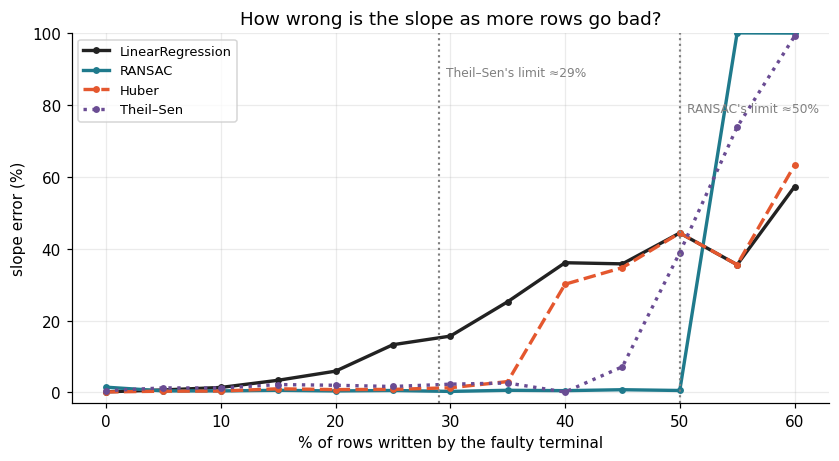

In [13]:
X0, y_clean, TRUE0 = make_regression(n_samples=600, n_features=1, noise=10,
                                     random_state=1, coef=True)
TRUE0 = float(TRUE0)

fracs = np.arange(0, .61, .05)
curves = {k: [] for k in ["LinearRegression", "RANSAC", "Huber", "Theil–Sen"]}

for f in fracs:
    y0 = y_clean.copy()
    k = int(600 * f)
    if k: y0[:k] = 600 + rng.normal(size=k)      # the same fault, spreading
    fit = {"LinearRegression": LinearRegression(),
           "RANSAC": RANSACRegressor(random_state=0),
           "Huber": HuberRegressor(epsilon=1.35, max_iter=1000),
           "Theil–Sen": TheilSenRegressor(random_state=0, max_subpopulation=3000)}
    for name, m in fit.items():
        m.fit(X0, y0)
        s = (m.estimator_ if name == "RANSAC" else m).coef_[0]
        curves[name].append(abs(s - TRUE0) / TRUE0 * 100)

fig, ax = plt.subplots(figsize=(7.8, 4.3))
for name, v in curves.items():
    ax.plot(fracs * 100, v, lw=2.2, marker="o", ms=3.5,
            c=colors[name], ls=styles[name], label=name)
ax.axvline(29, c="grey", ls=":", lw=1.4)
ax.axvline(50, c="grey", ls=":", lw=1.4)
ax.text(29.6, 88, "Theil–Sen's limit ≈29%", fontsize=8, color="grey")
ax.text(50.6, 78, "RANSAC's limit ≈50%", fontsize=8, color="grey")
ax.set(title="How wrong is the slope as more rows go bad?",
       xlabel="% of rows written by the faulty terminal",
       ylabel="slope error (%)", ylim=(-3, 100))
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

Read it left to right:

- **`LinearRegression`** starts drifting at the very first broken row and never
  stops. There is no safe amount of contamination for it.
- **Huber** holds flat for a long way and then bends. It softens far-away rows,
  it does not remove them, so enough of them eventually win.
- **Theil–Sen** holds further than its quoted 29%. That figure is a worst-case
  guarantee against contamination placed as badly as possible; a fault that
  writes one flat value is not the worst case.
- **RANSAC** is flat right up to 50%, then snaps. Past half the rows, the
  majority *is* the fault, and no method can know that the majority is wrong.

That last point is the honest limit of all of this: **robust regression assumes
the good data is the crowd.** If your fault is the crowd, nothing here saves
you — only knowing your data does.

## Common mistakes

1. **Using it to skip data cleaning.** These methods survive a fault; they do
   not tell you the terminal is broken. Read `inlier_mask_` and go fix the
   source.
2. **Leaving `residual_threshold` at the default when y is skewed.** The default
   is the median absolute deviation of `y`. On a heavily skewed target it can be
   far too wide, and the broken rows are quietly kept.
3. **Forgetting `random_state`.** RANSAC and Theil–Sen sample. Without a seed
   the line moves between runs, and nobody can reproduce your number.
4. **Scoring on the dirty test set.** If the test rows contain the same fault,
   the dishonest model looks better. Score on rows you trust.
5. **Using Theil–Sen on wide data.** It samples pairs and the cost grows fast
   with the number of columns. It is a small-data method.
6. **Plotting predictions with `plt.plot` on unsorted x.** A straight line
   survives it, anything else draws as a scribble. Sort x first, or use a
   `linspace` grid as every plot above does.

## Where this shows up in real systems

Anywhere a number arrives from something that can fail while still reporting:

- a sensor that returns its maximum reading when the cable is loose
- a payment or logging path that writes a default on timeout, exactly like
  Farhan's terminal
- scraped prices where a failed parse becomes `0`
- latency metrics where a restart writes one enormous value

The engineering habit that matches this is the one you already apply to a
monitoring dashboard: **quote the p50, not the mean**, because one bad node
should not decide the graph. RANSAC, Huber and Theil–Sen are that same instinct,
applied to a line instead of to a single column.

It is also the same idea as `RobustScaler` from feature scaling — median and IQR
instead of mean and standard deviation. Once you notice it, robustness is nearly
always "replace a mean with a median, or cap what one row can contribute".

## Key takeaway

**If you remember only one thing:** ordinary least squares squares the error, so
the row that is most wrong has the most influence — reverse that, and the line
belongs to the majority again. Reach for `RANSACRegressor` when you can afford
to discard rows and you want to know which ones, and `HuberRegressor` when you
want every row kept but tamed.